<h1>Reorganize order of fermatspiral scan</h1>

In [1]:
import sys
import os

# Add the path to the `simulated_recons/` folder to the Python path
sys.path.append(os.path.abspath("../../.."))
sys.path.insert(0, '/mxn/home/reblex/.local/lib/python3.8/site-packages')
import livedifferences

from ptypy import io
from ptypy.utils import rmphaseramp
import numpy as np
import re
import glob
from skimage.registration import phase_cross_correlation
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import scipy
import matplotlib.pyplot as plt
from scipy.ndimage import shift
from scipy.spatial import cKDTree
import collections
import h5py
import shutil


%matplotlib widget
plt.ion()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
WARNING ptypy - Message Passaging for Python (mpi4py) not found.
    CPU-parallelization disabled.
    Install python-mpi4py via the package repositories or with `pip install --user mpi4py`


<h2>Load data</h2>

In [2]:
scan = "000057"

npzfile = np.load("recon_info.npz", allow_pickle=True)
npzfile.files
offl_info = list(npzfile['offl_info'])
live_info = list(npzfile['live_info'])
livesim_info = list(npzfile['livesim_info'])


recset = []
#scanset = [recon for recon in offl_info+live_info if recon["sample"]=="siemens_big"]
recset = [recon for recon in offl_info+live_info if recon["scan"]==scan]
#recset_offl = [recon for recon in offl_info if recon["sample"]=="siemens_big"]
#recset_live = [recon for recon in live_info if recon["sample"]=="siemens_big"]

recset_live = [recon for recon in live_info if recon["scan"]==scan]

print(f"{recset_live[0]}")

# Load real live data
LD = livedifferences.LoadData(realtime_fname=recset_live[0]['rec_path'][0], samplename=scan)

LD.load()
LD.obj2.shape

{'scan': '000057', 'recfoldername': '000057_00', 'sample': 'broken_gold', 'nriter': 2461, 'rec_path': ['/data/visitors/nanomax/20250057/2025021508/process/RL/LivePtycho/broken_gold/000057_00/rec/rec_scan_000000_DM_pycuda_2461.ptyr'], 'rawdata_paths': ['/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/000057.h5', '/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/scan_000057_eiger1m.hdf5']}


(3669, 3669)

<h3>Load positions</h3>

In [3]:
rawpath = [path for path in recset_live[0]['rawdata_paths'] if path.endswith('.h5')][0]
x = io.h5read(rawpath, 'entry/measurement/pseudo/x')['entry/measurement/pseudo/x']  # in micrometers
y = io.h5read(rawpath, 'entry/measurement/pseudo/y')['entry/measurement/pseudo/y']  # in micrometers
pos = np.stack((x,y),axis=0)


In [4]:
pos[0,:3], x[:3], len(pos[0]), np.sqrt(4180)


(array([ -7.68488415,  14.8367806 , -14.42185573]),
 array([ -7.68488415,  14.8367806 , -14.42185573]),
 4180,
 64.65291950097846)

In [5]:
1200/3664

0.32751091703056767

<h2>Plot original positions</h2>

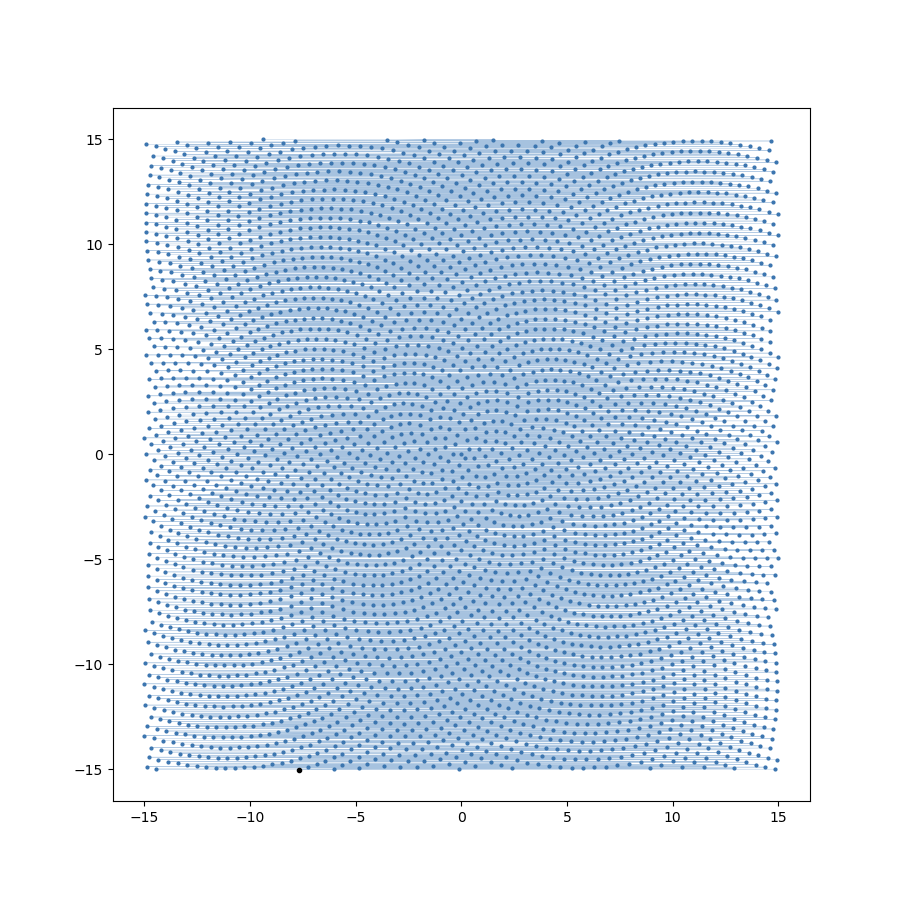

In [6]:
default_blue=np.array([59/255, 117/255, 175/255]) # default blue color, #3B75AF
light_blue=np.array([166/255, 194/255, 223/255]) # #A6C2DF

plt.figure(figsize=(9,9))
plt.plot(x,y, lw=0.3, ms=2, c=light_blue)
plt.plot(x,y, 'o', ms=2, c=default_blue)
plt.plot(x[0],y[0], 'o', ms=3, c=(0,0,0)) # First scanning position is black.



<h2>--------------------------------------------------------------------------------------------------------</h2>

<h2>Define functions</h2>

In [7]:
def maxstep(arr):
    """
    Parameters
    ----------
    arr : ndarray
        Array of shape (2, N) where N is the number of positions.

    Returns
    -------
    float
        The maximun distance between one position to the next in line.

    """
    return np.max(np.linalg.norm(np.diff(arr, axis=1), axis=0))

def minstep(arr):
    """
    Parameters
    ----------
    arr : ndarray
        Array of shape (2, N) where N is the number of positions.

    Returns
    -------
    float
        The minimum distance between one position to the next in line.

    """
    return np.min(np.linalg.norm(np.diff(arr, axis=1), axis=0))


def stepstat(arr):
    """
    Parameters
    ----------
    arr : ndarray
        Array of shape (2, N) where N is the number of positions.

    Returns
    -------
    float
        The minimum distance between one position to the next in line.

    """
    
    minstep_ = minstep(arr)
    maxstep_ = maxstep(arr)
    meanstep_ = np.mean(np.linalg.norm(np.diff(arr, axis=1), axis=0))
    medianstep_ = np.median(np.linalg.norm(np.diff(arr, axis=1), axis=0))
    stdstep_ = np.std(np.linalg.norm(np.diff(arr, axis=1), axis=0))
    return minstep_, maxstep_, meanstep_, medianstep_, stdstep_




def sort_dist2center(arr):
    """
    Calculates distance to the center, origo, and sorts an array accordingly.
    
    Parameters
    ----------
    arr : ndarray
        Array of shape (2, N) where N is the number of positions.

    Returns
    -------
    d2c_ind : ndarray
        Index array that sorts arr according to shortest distance to the center.
    d2c_sorted : ndarray
        Array of distances sorted from smallest to largest.
    arr_sorted : ndarray
        Input array sorted by the distances.

    """
    d2c = np.sqrt(arr[0,:]**2 + arr[1,:]**2) # distance to center
    d2c_ind = np.argsort(d2c)
    d2c_sorted = d2c[d2c_ind]
    arr_sorted = arr[:,d2c_ind]
    
    return d2c_ind, d2c_sorted, arr_sorted
    
#sort_ind, d2c_sorted, pos_sorted = sort_dist2center(pos)
    
def verify_unique(data):
    """
    Checks if there are any duplicates in the input.
    
    Parameters
    ----------
    data : ndarray or list of integers
        Array of shape (2, N) where N is the number of positions, or list of integers.

    Returns
    -------
    bool
        True if all elements are unique, False if duplicates are found,

    """
    if isinstance(data, list):
        search_list = data
    elif isinstance(data, np.ndarray):
        # Convert to list of arrays
        arr_list = list(data.T)
        # Convert each array to a tuple
        search_list = [tuple(arr) for arr in arr_list]
        
    # Find duplicates
    seen = set()
    duplicates = set()
    dup_indexes = []
    for ind, item in enumerate(search_list):
        if item in seen:
            duplicates.add(item)
            dup_indexes.append(ind)
        else:
            seen.add(item)
    if len(duplicates) == 0:
        print("No duplicates found")
        return True
    elif len(duplicates) > 0:
        print(f"{len(duplicates)} Duplicates found:\n    {list(duplicates)}")
        return False


def greedy_nearest_neighbor_with_origin_bias(coords, k=5):
    N = coords.shape[1]
    visited = np.zeros(N, dtype=bool)
    order = []

    # Start from the point closest to the origin
    current_idx = np.argmin(np.sum(coords**2, axis=0))
    order.append(current_idx)
    visited[current_idx] = True

    tree = cKDTree(coords.T)

    for _ in range(N - 1):
        current_point = coords[:, current_idx]

        # Try increasing number of neighbors until at least one valid candidate is found
        search_k = k
        while True:
            search_k = min(search_k + 5, N)  # Expand gradually up to all points
            dists, idxs = tree.query(current_point, k=search_k)
            if np.isscalar(idxs):
                idxs = [idxs]
            candidates = [idx for idx in idxs if not visited[idx] and idx != current_idx]
            if candidates:
                break
            if search_k >= N:
                # No more unvisited candidates
                break

        if not candidates:
            print(f'No more candidates at step {_}, picking remaining unvisited point.')
            # Fallback: pick the unvisited point closest to current point
            remaining = np.where(~visited)[0]
            dists_to_remaining = np.linalg.norm(coords[:, remaining] - current_point[:, None], axis=0)
            current_idx = remaining[np.argmin(dists_to_remaining)]
        else:
            # Choose next from candidates, biased toward the origin
            origin_dists = np.sum(coords[:, candidates]**2, axis=0)
            current_idx = candidates[np.argmin(origin_dists)]

        order.append(current_idx)
        visited[current_idx] = True

    return coords[:, order], order



In [8]:
print(pos[:,:5])
print(np.sum(pos[:, :5]**2, axis=0))
print( (-7.68488415)**2+(-15.0058871)**2, (14.8367806)**2+(-14.98996901)**2 )

[[ -7.68488415  14.8367806  -14.42185573  -0.09177334  -6.03984936]
 [-15.0058871  -14.98996901 -14.98401745 -14.97399108 -14.96981208]]
[284.2340921  444.82922949 432.51070164 224.22883121 260.57505401]
284.23409205686767 444.8292294932968


In [9]:
# Get the rearranged positions
num_nb = 5
reordered_coords, order = greedy_nearest_neighbor_with_origin_bias(pos, k=num_nb)

# Sanity check:
verify_unique(reordered_coords)
minstep_, maxstep_, meanstep_, medianstep_, stdstep_ = stepstat(reordered_coords)
print(f"num_nb: {num_nb},    minstep: {minstep_:.6f}, maxstep: {maxstep_:.6f}, meanstep: {meanstep_:.6f}, medianstep: {medianstep_:.6f}, stdstep: {stdstep_:.6f}")



"""
num_nb: 2,     minstep: 0.264507, maxstep: 19.564217, meanstep: 0.534730, medianstep: 0.498069, stdstep: 0.430040
num_nb: 3,     minstep: 0.264507, maxstep: 19.564217, meanstep: 0.595300, medianstep: 0.559837, stdstep: 0.524650
num_nb: 4,     minstep: 0.264507, maxstep: 34.566646, meanstep: 0.625796, medianstep: 0.595157, stdstep: 0.636439
num_nb: 5,     minstep: 0.264507, maxstep: 19.859858, meanstep: 0.658480, medianstep: 0.636386, stdstep: 0.475749
num_nb: 6,     minstep: 0.264507, maxstep: 23.773901, meanstep: 0.680214, medianstep: 0.658215, stdstep: 0.521623
num_nb: 7,     minstep: 0.264507, maxstep: 23.040268, meanstep: 0.705341, medianstep: 0.687196, stdstep: 0.528249
num_nb: 8,     minstep: 0.264507, maxstep: 35.417873, meanstep: 0.746906, medianstep: 0.735184, stdstep: 0.661271
num_nb: 9,     minstep: 0.264507, maxstep: 19.675503, meanstep: 0.752453, medianstep: 0.742048, stdstep: 0.513059
num_nb: 10,    minstep: 0.264507, maxstep: 19.602190, meanstep: 0.757112, medianstep: 0.746014, stdstep: 0.463672
num_nb: 15,    minstep: 0.264507, maxstep: 17.713324, meanstep: 0.853188, medianstep: 0.838377, stdstep: 0.470006
num_nb: 20,    minstep: 0.264507, maxstep: 18.746532, meanstep: 0.960368, medianstep: 0.959114, stdstep: 0.503181


""";

No duplicates found
num_nb: 5,    minstep: 0.264708, maxstep: 19.859868, meanstep: 0.658485, medianstep: 0.636449, stdstep: 0.475742


(4179,)


Text(0.5, 1.0, 'num_nb: 5')

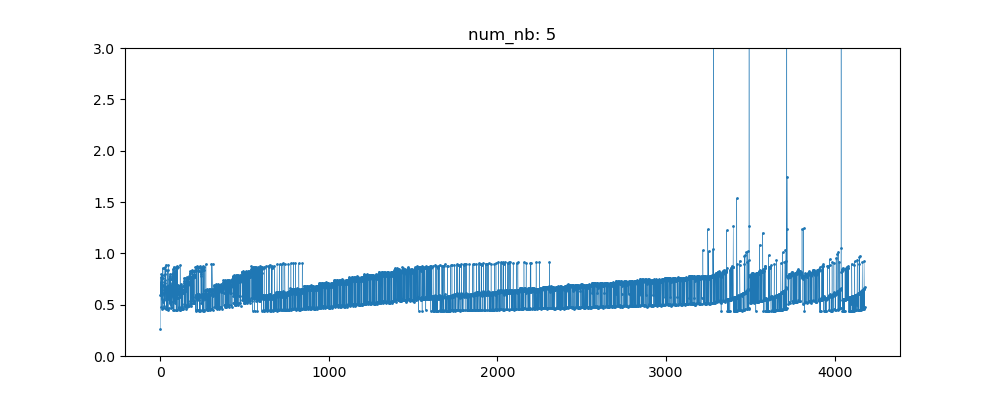

In [10]:
steps = np.linalg.norm(np.diff(reordered_coords, axis=1), axis=0)
print(steps.shape)
np.where(steps >= 1)
plt.figure(figsize=(10,4))
pl=plt.plot(steps,'o-', ms=1, lw=0.3)
pl_=pl[0]
pl_.axes.set_ylim(0,3)
plt.title(f"num_nb: {num_nb}")

<h2>Plot positions sorted by nearest neighbor with origin bias</h2>

In [11]:
#%prun?

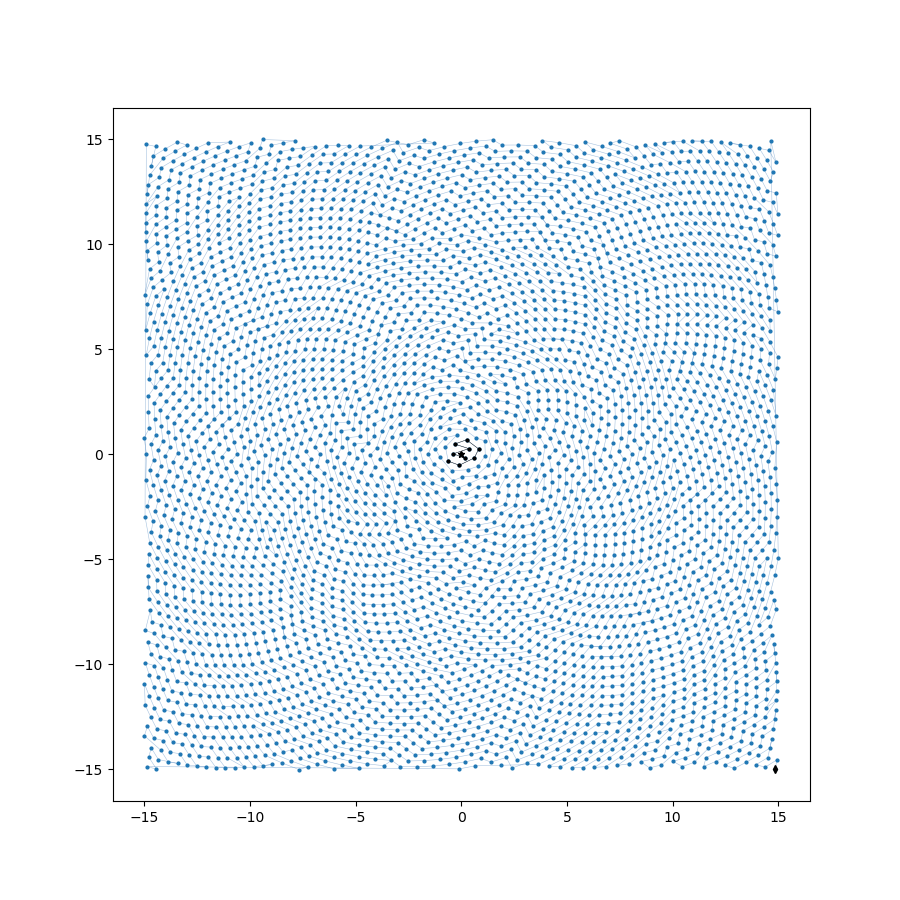

In [12]:
if "fig" in list(globals().keys()):
    fig.clf()


fig = plt.figure(figsize=(9,9))
#plt.plot(reordered_coords[0,:],reordered_coords[1,:], lw=0.3, ms=2, c=light_blue)
#plt.plot(reordered_coords[0,:],reordered_coords[1,:], 'o', ms=2, c=default_blue)

marker_style = dict(linestyle='-', linewidth=0.4, color=light_blue, markersize=2,
                    markerfacecolor="tab:blue", markeredgecolor="tab:blue")
plt.plot(reordered_coords[0,:],reordered_coords[1,:],'o',**marker_style)#'lo' ,lw=0.3, ms=2, mfc='r', mec='r')

plt.plot(reordered_coords[0,0],reordered_coords[1,0], '*', ms=5, c='k') # Center/first scanning position is a big black star.
plt.plot(reordered_coords[0,0:10],reordered_coords[1,0:10], '-o', lw=0.3, ms=2, c='k') # First scanning positions are black.
plt.plot(reordered_coords[0,-1],reordered_coords[1,-1], 'd', ms=4, c='k') # Last scanning position is a big black diamond.
plt.show()

<h3>Plot with color gradiant instead</h3>

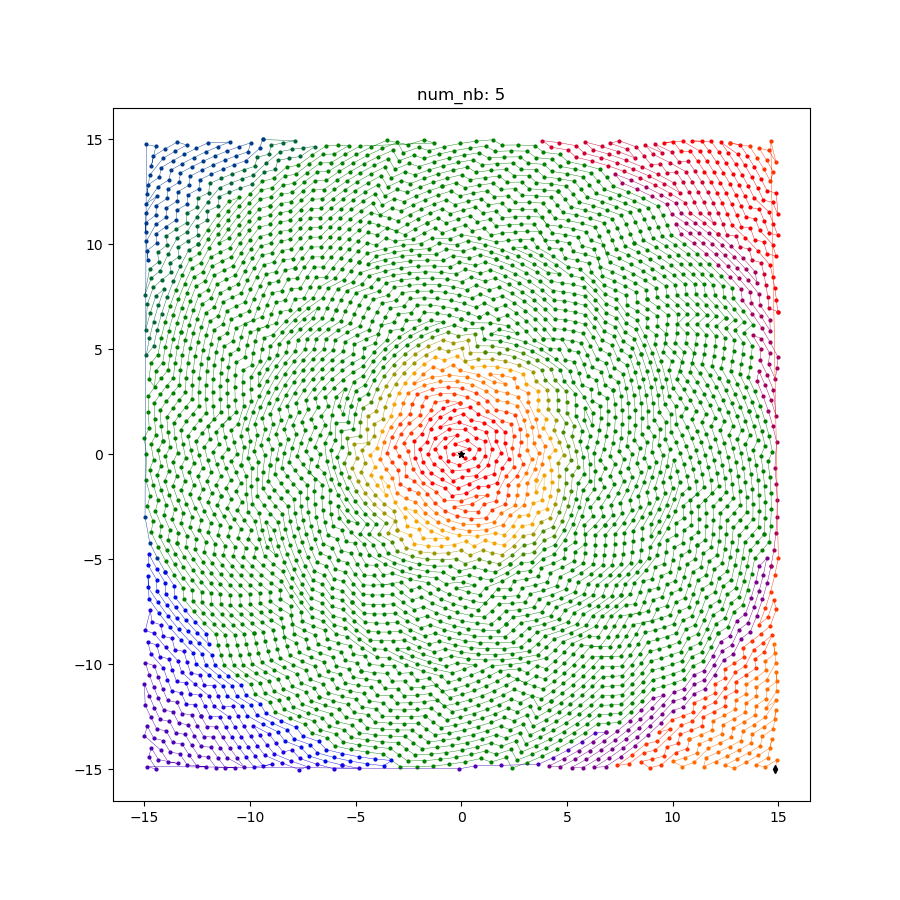

In [13]:
# Plot gradually changing color plot, this code is modified from:
# https://abhigupta.io/2022/07/23/gradient-in-matplotlib.html

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

def colorFader(c1, c2, mix=0):
    c1 = np.array(mpl.colors.to_rgb(c1))
    c2 = np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1 - mix) * c1 + mix * c2)

# Define 5 colors to transition through
#colors = ['red', 'red', 'red', 'red', 'red', 'red', 'red', 'orange', 'green', 'blue', 'purple']
colors = ['red']*1 + \
      ['orange']*1 + \
       ['green']*13 + \
       ['green']*1 + \
        ['blue']*1 + \
      ['purple']*1 + \
    ['red']*1 + \
    ['orange']*1

# Example coordinates (spiral for demo)
n = reordered_coords.shape[-1]

fig, ax = plt.subplots(figsize=(9,9))
cstep = 76  # should be a number dividable with number of positions:
# for divnum in range(1,500):
#     if 4180%divnum == 0:
#         print(f'Dividable with {divnum},   4180/{divnum} = {4180/divnum}')


# Plot with color transitions through all color segments
for i in range(1, n + 1, cstep):
    frac = i / n
    total_segments = len(colors) - 1
    segment = min(int(frac * total_segments), total_segments - 1)
    local_frac = (frac - segment / total_segments) * total_segments

    c1 = colors[segment]
    c2 = colors[segment + 1]
    color = colorFader(c1, c2, local_frac)

    ax.plot(
        reordered_coords[0, i - 1:i + cstep],
        reordered_coords[1, i - 1:i + cstep],
        '-o', color=color, lw=0.3, ms=2
    )
plt.plot(reordered_coords[0,0],reordered_coords[1,0], '*', ms=5, c=(0,0,0)) # Center/first scanning position is a big black star.
plt.plot(reordered_coords[0,-1],reordered_coords[1,-1], 'd', ms=4, c=(0,0,0)) # Last scanning position is a big black diamond.
plt.title(f"num_nb: {num_nb}")
plt.show()


Dividable with 1,   4180/1 = 4180.0
Dividable with 2,   4180/2 = 2090.0
Dividable with 4,   4180/4 = 1045.0
Dividable with 5,   4180/5 = 836.0
Dividable with 10,   4180/10 = 418.0
Dividable with 11,   4180/11 = 380.0
Dividable with 19,   4180/19 = 220.0
Dividable with 20,   4180/20 = 209.0
Dividable with 22,   4180/22 = 190.0
Dividable with 38,   4180/38 = 110.0
Dividable with 44,   4180/44 = 95.0
Dividable with 55,   4180/55 = 76.0
Dividable with 76,   4180/76 = 55.0
Dividable with 95,   4180/95 = 44.0
Dividable with 110,   4180/110 = 38.0
Dividable with 190,   4180/190 = 22.0
Dividable with 209,   4180/209 = 20.0
Dividable with 220,   4180/220 = 19.0
Dividable with 380,   4180/380 = 11.0
Dividable with 418,   4180/418 = 10.0


<h2>--------------------------------------------------------------------------------------------------------</h2>

<h2>Rearrange raw files</h2>

In [72]:
recset_live[0]['rawdata_paths']
rawfnames=recset_live[0]['rawdata_paths']

h5_raw_fname = [fname for fname in rawfnames if fname.endswith('.h5')][0]
h5_raw_fname, recset_live[0]['rawdata_paths']

('/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/000057.h5',
 ['/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/000057.h5',
  '/data/visitors/nanomax/20250057/2025021508/raw/0001_setup/scan_000057_eiger1m.hdf5'])

In [73]:
fnames=recset_live[0]['rawdata_paths']

import h5py


# Get raw fnames
rawfnames=recset_live[0]['rawdata_paths']
h5_raw_fname = [fname for fname in rawfnames if fname.endswith('.h5')][0]
hdf5_raw_fname = [fname for fname in rawfnames if fname.endswith('.hdf5')][0]

# Make temporary copy of files to be extra sure nothing happens with original data
source_h5 = h5_raw_fname
source_hdf5 = hdf5_raw_fname
dest = '/data/visitors/nanomax/20250057/2025021508/process/RL/new_raw_data/'
dest_h5 = dest + 'tmp/' + h5_raw_fname.rsplit('/',1)[1]
dest_hdf5 = dest + 'tmp/' + hdf5_raw_fname.rsplit('/',1)[1]
shutil.copy2(src=source_h5, dst=dest_h5)
shutil.copy2(src=source_hdf5, dst=dest_hdf5)

# Use the copied files to read data et.c
h5_raw_fname = dest_h5
hdf5_raw_fname = dest_hdf5
print('copied original files')

new_h5_fname = dest + h5_raw_fname.rsplit('/',1)[1]
new_hdf5_fname = dest + hdf5_raw_fname.rsplit('/',1)[1]


# Prepare new h5 data
pseudo_x = reordered_coords[0,:]
pseudo_y = reordered_coords[1,:]

# write new h5 file
f_h5_raw = h5py.File(h5_raw_fname, 'r')
f_h5 = h5py.File(new_h5_fname, 'w')
f_h5_raw.copy(source='entry', dest=f_h5)
f_h5['entry']['measurement']['pseudo'].pop('x')
f_h5['entry']['measurement']['pseudo'].pop('y')
f_h5['entry']['measurement']['pseudo'].create_dataset(name='x', data=pseudo_x)
f_h5['entry']['measurement']['pseudo'].create_dataset(name='y', data=pseudo_y)

f_h5_raw.close()
f_h5.close()

print('wrote new h5 file')

# Prepare new hdf5 data
f_hdf5_raw = h5py.File(hdf5_raw_fname, 'r')
diff_data = f_hdf5_raw['entry']['instrument']['Eiger']['data'][...]
diff_data_sorted = diff_data[order]

# write new hdf5 file

f_hdf5 = h5py.File(new_hdf5_fname, 'w')
f_hdf5_raw.copy(source='entry', dest=f_hdf5)
f_hdf5['entry']['instrument']['Eiger'].pop('data') ## shape: {4180/Inf, 1062, 1028}
f_hdf5['entry']['instrument']['Eiger'].create_dataset(name='data', data=diff_data_sorted, compression='lzf', shuffle=True, chunks=True)  # 'gzip', 'szip', 'lzf'. , chunks=True

f_hdf5_raw.close()
f_hdf5.close()

print('wrote new hdf5 file')

#os.remove(dest_h5)
#os.remove(dest_hdf5)



copied original files
wrote new h5 file
wrote new hdf5 file


<h3>Double check new files</h3>

In [ ]:
# rawfnames=recset_live[0]['rawdata_paths']
# h5_raw_fname = [fname for fname in rawfnames if fname.endswith('.h5')][0]
# hdf5_raw_fname = [fname for fname in rawfnames if fname.endswith('.hdf5')][0]

# # Make temporary copy of files to be extra sure nothing happens with original data
# source_h5 = h5_raw_fname
# source_hdf5 = hdf5_raw_fname
# dest = '/data/visitors/nanomax/20250057/2025021508/process/RL/new_raw_data/'
# dest_h5 = dest + 'tmp/' + h5_raw_fname.rsplit('/',1)[1]
# dest_hdf5 = dest + 'tmp/' + hdf5_raw_fname.rsplit('/',1)[1]

# h5_raw_fname = dest_h5
# hdf5_raw_fname = dest_hdf5

# new_h5_fname = dest + h5_raw_fname.rsplit('/',1)[1]
# new_hdf5_fname = dest + 'gzipchunks_' + hdf5_raw_fname.rsplit('/',1)[1]#dest + hdf5_raw_fname.rsplit('/',1)[1]
#########################
from pprint import pp as pprint
import time
print(f"source_h5:      {source_h5}\nsource_hdf5:    {source_hdf5}\nnew_h5_fname:   {new_h5_fname}\nnew_hdf5_fname: {new_hdf5_fname}\n")

h5_raw_data = io.h5read(source_h5)
hdf5_raw_data = io.h5read(source_hdf5)

h5_new_data = io.h5read(new_h5_fname)
t0 = time.time()
hdf5_new_data = io.h5read(new_hdf5_fname)
print(f'loading new hdf5 took {time.time()-t0} s.')

"""
gzip_scan_000047_eiger1m.hdf5: loading new hdf5 took 52.62868809700012 s.
lzf_scan_000047_eiger1m.hdf5:  loading new hdf5 took 42.47586131095886 s.
lzfchunks_scan_000047_eiger1m.hdf5:  loading new hdf5 took 39.41644358634949 s.
""";

In [ ]:
#pprint(hdf5_raw_data['entry']['instrument']['Eiger'],'\n')
hdf5_raw_diff = hdf5_raw_data['entry']['instrument']['Eiger']['data']

############################################################################
#pprint(hdf5_new_data['entry']['instrument']['Eiger'],'\n')
hdf5_new_diff = hdf5_new_data['entry']['instrument']['Eiger']['data']

############################################################################
pprint(str(h5_raw_data['entry']['measurement']['pseudo'])+'\n')  ## measurement keys:  dict_keys(['alba2', 'dt', 'eiger1m', 'panda0', 'pseudo', 'sx', 'sy'])
print('')
#pprint(h5_raw_data['entry']['measurement']['eiger1m']['frames'],'\n')
h5_raw_diff = h5_raw_data['entry']['measurement']['eiger1m']['frames']

############################################################################
pprint(str(h5_new_data['entry']['measurement']['pseudo'])+'\n')  # entrykeys:  dict_keys(['contrast_version', 'description', 'measurement', 'snapshots'])
print('')
#pprint(h5_new_data['entry']['measurement']['eiger1m']['frames'],'\n')
h5_new_diff = h5_new_data['entry']['measurement']['eiger1m']['frames']


############################################################################
############################################################################
print((h5_raw_diff == h5_new_diff).all())     # Should be False
print((hdf5_raw_diff == hdf5_new_diff).all()) # Should be False

print((h5_raw_diff == hdf5_raw_diff).all())   # Should be True
print((h5_new_diff == hdf5_new_diff).all())   # Should be True
############################################################################
## order[:3] = [2093, 2066, 2098]
print((hdf5_raw_diff[order[0]] == hdf5_new_diff[0]).all())  # Should be True
print((hdf5_raw_diff[order[1]] == hdf5_new_diff[1]).all())  # Should be True

print((hdf5_raw_diff[order[0]] == hdf5_new_diff[0]).all())  # Should be True
print((hdf5_raw_diff[order[1]] == hdf5_new_diff[1]).all())  # Should be True
############################################################################

In [ ]:
# timing loading stuff
import time
dest = '/data/visitors/nanomax/20250057/2025021508/process/RL/new_raw_data/'
fn1 = 'scan_000047_eiger1m.hdf5'
fn2 = 'chunks_scan_000047_eiger1m.hdf5'
fn3 = 'gzip_scan_000047_eiger1m.hdf5'
fn4 = 'gzipchunks_scan_000047_eiger1m.hdf5'
fn5 = 'lzf_scan_000047_eiger1m.hdf5'
fn6 = 'lzfchunks_scan_000047_eiger1m.hdf5'
fn7 = 'lzfchunksshuffle_scan_000047_eiger1m.hdf5'


t00 = time.time()
h5_data_ = io.h5read('/data/visitors/nanomax/20250057/2025021508/process/RL/new_raw_data/000047.h5', 'entry')['entry']
print(f'loading time for h5:  {time.time()-t00} s.')



t6 = time.time()
hdf5_new_data______ = io.h5read(dest+fn7, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
print(f'loading time for {fn7.ljust(37," ")}: {time.time()-t6} s.')

# t5 = time.time()
# hdf5_new_data______ = io.h5read(dest+fn6, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn6.ljust(37," ")}: {time.time()-t5} s.')

# t4 = time.time()
# hdf5_new_data_____ = io.h5read(dest+fn5, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn5.ljust(37," ")}: {time.time()-t4} s.')

# t3 = time.time()
# hdf5_new_data____ = io.h5read(dest+fn4, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn4.ljust(37," ")}: {time.time()-t3} s.')

# t2 = time.time()
# hdf5_new_data___ = io.h5read(dest+fn3, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn3.ljust(37," ")}: {time.time()-t2} s.')

# t1 = time.time()
# hdf5_new_data__ = io.h5read(dest+fn2, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn2.ljust(37," ")}: {time.time()-t1} s.')

# t0 = time.time()
# hdf5_new_data_ = io.h5read(dest+fn1, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn1.ljust(37," ")}: {time.time()-t0} s.')
##

# t0 = time.time()
# hdf5_new_data_ = io.h5read(dest+fn1, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn1.ljust(37," ")}: {time.time()-t0} s.')

# t1 = time.time()
# hdf5_new_data__ = io.h5read(dest+fn2, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn2.ljust(37," ")}: {time.time()-t1} s.')

# t2 = time.time()
# hdf5_new_data___ = io.h5read(dest+fn3, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn3.ljust(37," ")}: {time.time()-t2} s.')

# t3 = time.time()
# hdf5_new_data____ = io.h5read(dest+fn4, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn4.ljust(37," ")}: {time.time()-t3} s.')

# t4 = time.time()
# hdf5_new_data_____ = io.h5read(dest+fn5, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn5.ljust(37," ")}: {time.time()-t4} s.')

# t5 = time.time()
# hdf5_new_data______ = io.h5read(dest+fn6, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn6.ljust(37," ")}: {time.time()-t5} s.')

# t6 = time.time()
# hdf5_new_data_______ = io.h5read(dest+fn1, '/entry/instrument/Eiger/data')['/entry/instrument/Eiger/data']
# print(f'loading time for {fn1.ljust(37,' ')}: {time.time()-t6} s.')

"""
loading time for h5:  6.828692436218262 s.
loading time for scan_000047_eiger1m.hdf5             : 6.15683126449585 s.
loading time for chunks_scan_000047_eiger1m.hdf5      : 28.57331871986389 s.
loading time for gzip_scan_000047_eiger1m.hdf5        : 59.82896590232849 s.

loading time for h5:  6.751960754394531 s.
loading time for scan_000047_eiger1m.hdf5             : 6.2215471267700195 s.
loading time for chunks_scan_000047_eiger1m.hdf5      : 18.210970640182495 s.
loading time for gzip_scan_000047_eiger1m.hdf5        : 50.629687786102295 s.
loading time for gzipchunks_scan_000047_eiger1m.hdf5  : 50.95941638946533 s.
loading time for lzf_scan_000047_eiger1m.hdf5         : 40.97630023956299 s.
loading time for lzfchunks_scan_000047_eiger1m.hdf5   : 41.02283000946045 s.

loading time for h5:  7.550588846206665 s.
loading time for lzfchunks_scan_000047_eiger1m.hdf5   : 37.5466582775116 s.
loading time for lzf_scan_000047_eiger1m.hdf5         : 37.57614302635193 s.
loading time for gzipchunks_scan_000047_eiger1m.hdf5  : 51.04336762428284 s.
loading time for gzip_scan_000047_eiger1m.hdf5        : 50.498788833618164 s.
loading time for chunks_scan_000047_eiger1m.hdf5      : 18.372359037399292 s.
loading time for scan_000047_eiger1m.hdf5             : 6.853206157684326 s.
""";

<h2>--------------------------------------------------------------------------------------------------------</h2>

<h2>--------------------------------------------------------------------------------------------------------</h2>

<h2>--------------------------------------------------------------------------------------------------------</h2>

In [79]:
y20 = y[:20]
print(y20)
y20[:-1]
print(y20[1:]-y20[:-1])
print(np.where(y[1:]-y[:-1] <= 0))
print(y[:30])

[-15.0058871  -14.98996901 -14.98401745 -14.97399108 -14.96981208
 -14.95664178 -14.95008661 -14.93806649 -14.9287241  -14.92697865
 -14.92464978 -14.91862223 -14.91444318 -14.91138446 -14.90707616
 -14.90465773 -14.89115674 -14.88698767 -14.88295831 -14.88172787]
[0.01591809 0.00595156 0.01002637 0.004179   0.0131703  0.00655517
 0.01202012 0.00934239 0.00174545 0.00232887 0.00602755 0.00417905
 0.00305872 0.0043083  0.00241843 0.01350099 0.00416907 0.00402936
 0.00123044]
(array([  25,   53,   78,  170,  449,  602,  784,  906, 1094, 1399, 1517,
       1535, 1729, 1817, 1999, 2027, 2280, 2558, 2638, 2697, 2738, 2750,
       2830, 3000, 3038, 3212, 3360, 3527, 3939]),)
[-15.0058871  -14.98996901 -14.98401745 -14.97399108 -14.96981208
 -14.95664178 -14.95008661 -14.93806649 -14.9287241  -14.92697865
 -14.92464978 -14.91862223 -14.91444318 -14.91138446 -14.90707616
 -14.90465773 -14.89115674 -14.88698767 -14.88295831 -14.88172787
 -14.87488022 -14.87450519 -14.87135427 -14.86951825 -14.8

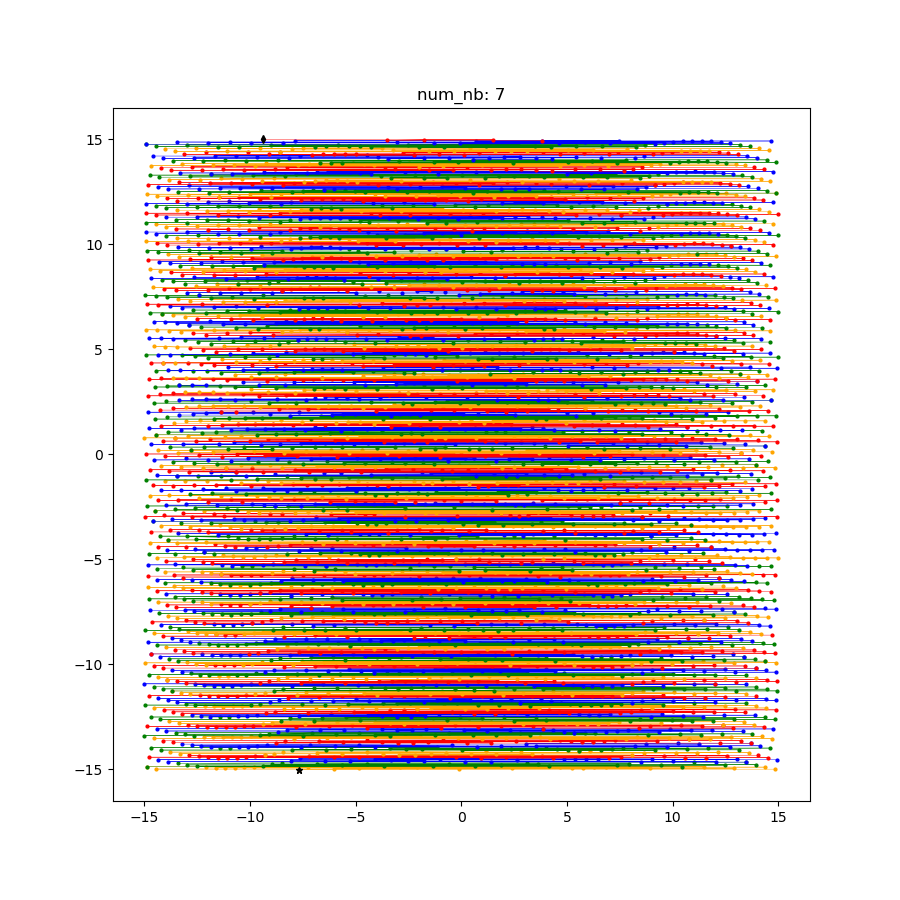

In [62]:
# Plot gradually changing color plot, this code is modified from:
# https://abhigupta.io/2022/07/23/gradient-in-matplotlib.html

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

def colorFader(c1, c2, mix=0):
    c1 = np.array(mpl.colors.to_rgb(c1))
    c2 = np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1 - mix) * c1 + mix * c2)

# Define 5 colors to transition through
#colors = ['red', 'red', 'red', 'red', 'red', 'red', 'red', 'orange', 'green', 'blue', 'purple']
colors = ['red']*1 + \
      ['orange']*1 + \
       ['green']*1 + \
        ['blue']*1# + \
      #['purple']*1
# Example coordinates (spiral for demo)
n = reordered_coords.shape[-1]

fig, ax = plt.subplots(figsize=(9,9))
cstep = 25  # should be a number dividable with number of positions:
# for divnum in range(1,500):
#     if 4180%divnum == 0:
#         print(f'Dividable with {divnum},   4180/{divnum} = {4180/divnum}')


# Plot with color transitions through all color segments
for i in range(1, n + 1, cstep):
    frac = i / n
    total_segments = len(colors) - 1
    segment = min(int(frac * total_segments), total_segments - 1)
    local_frac = (frac - segment / total_segments) * total_segments

    c1 = colors[segment]
    c2 = colors[segment + 1]
    color = colorFader(c1, c2, local_frac)

    ax.plot(
        pos[0, i - 1:i + cstep],
        pos[1, i - 1:i + cstep],
        '-o', color=colors[i%4], lw=0.3, ms=2
    )
plt.plot(pos[0,0],pos[1,0], '*', ms=5, c=(0,0,0)) # Center/first scanning position is a big black star.
plt.plot(pos[0,-1],pos[1,-1], 'd', ms=4, c=(0,0,0)) # Last scanning position is a big black diamond.
plt.title(f"num_nb: {num_nb}")
plt.show()


<h2>Plot positions sorted by distance to center</h2>

In [ ]:
pos=np.stack((x,y),axis=0)
center_dist = np.sqrt(pos[0,:]**2 + pos[1,:]**2) # distance to center
sort_ind = np.argsort(center_dist)
center_dist_sorted = center_dist[sort_ind]
x_sorted = x[sort_ind]
y_sorted = y[sort_ind]
pos.shape, center_dist.shape


default_blue=np.array([59/255, 117/255, 175/255]) # default blue color, #3B75AF
light_blue=np.array([166/255, 194/255, 223/255]) # #A6C2DF

plt.figure(figsize=(9,9))
plt.plot(x_sorted,y_sorted, lw=0.3, ms=2, c=light_blue)
plt.plot(x_sorted,y_sorted, 'o', ms=2, c=default_blue)
plt.plot(x_sorted[0],y_sorted[0], '*', ms=5, c=(0,0,0)) # Center scanning position is a big black star.
plt.plot(x_sorted[:20],y_sorted[:20], '-o', lw=0.3, ms=2, c=(0,0,0)) # First scanning position is black.

#plt.axis([-1, 1, -1, 1])

In [ ]:
sort_ind = np.argsort(center_dist)
center_dist[sort_ind]
sort_ind.shape, center_dist[sort_ind][:10]

In [ ]:
x[sort_ind].shape

In [ ]:
pos.shape

<h2>Combine nearest neighbour and closest to center</h2>

In [ ]:
posT=np.stack((x,y),axis=1)
print(f'pos.shape: {pos.shape}, posT.shape: {posT.shape}')
center_distT = np.sqrt(posT[:,0]**2 + posT[:,1]**2) # distance to center
print(f'center_dist.shape: {center_dist.shape}, center_distT.shape: {center_distT.shape}')

In [ ]:
# combine nearest neighbour and closest to center

pos=np.stack((x,y),axis=1)
center_dist = np.sqrt(pos[:,0]**2 + pos[:,1]**2) # distance to center
sort_ind = np.argsort(center_dist)
center_dist_sorted = center_dist[sort_ind]
pos_sorted = pos[sort_ind]
x_sorted = x[sort_ind]
y_sorted = y[sort_ind]
print(f'pos.shape: {pos.shape}\ncenter_dist.shape: {center_dist.shape}\nsort_ind.shape: {sort_ind.shape}\npos_sorted.shape: {pos_sorted.shape}')

tree = cKDTree(pos_sorted)  # Build a KDTree for fast nearest neighbor queries
new_positions = [tuple(pos_sorted[0])]  # Start with the center position
    
    
# Loop through the positions sorted by distance to center 
for i,p in enumerate(pos_sorted):  # p.shape = (2,)
    # Find nearest neighbours to most recently added position 
    query_index = sort_ind[i]
    query_point = new_positions[-1]##pos[query_index]###pos_sorted[query_index]
    dists, indices = tree.query(query_point, k=5)
    nearest_indices = indices[1:5]
    
    # Find which one of the nearest neighbours that are closest to center
    nn = pos_sorted[nearest_indices]
    center_dist_nn = np.sqrt(nn[:,0]**2 + nn[:,1]**2)
    sort_ind_nn = np.argsort(center_dist_nn)
    for k in range(len(sort_ind_nn)):
        candidate = tuple(nn[sort_ind_nn[k]])
        if candidate in new_positions:
            #print(f'found duplicate: {candidate}')
            continue
        else:
            next_pos = candidate
            #print(f'found candidate nr {i}: {candidate}')
            break
    new_positions.append(next_pos)


In [ ]:
# combine nearest neighbour and closest to center, using functions

pos=np.stack((x,y),axis=1)
center_dist = np.sqrt(pos[:,0]**2 + pos[:,1]**2) # distance to center
sort_ind = np.argsort(center_dist)
center_dist_sorted = center_dist[sort_ind]
pos_sorted = pos[sort_ind]
x_sorted = x[sort_ind]
y_sorted = y[sort_ind]
print(f'pos.shape: {pos.shape}\ncenter_dist.shape: {center_dist.shape}\nsort_ind.shape: {sort_ind.shape}\npos_sorted.shape: {pos_sorted.shape}')

tree = cKDTree(pos_sorted)  # Build a KDTree for fast nearest neighbor queries
new_positions = [tuple(pos_sorted[0])]  # Start with the center position
pos_sorted_ = pos_sorted.copy()


def find_nn(num_neighbours=5):
    # Find nearest neighbours to most recently added position 
    query_index = sort_ind[i]
    query_point = new_positions[-1]##pos[query_index]###pos_sorted[query_index]
    dists, indices = tree.query(query_point, k=num_neighbours)
    nearest_indices = indices[1:num_neighbours]
    nn = pos_sorted[nearest_indices]
    
    # Find which one of the nearest neighbours that are closest to center
    center_dist_nn = np.sqrt(nn[:,0]**2 + nn[:,1]**2)
    sort_ind_nn = np.argsort(center_dist_nn)
    
    return query_index, query_point, dists, indices, nearest_indices, nn, center_dist_nn, sort_ind_nn


def find_candidate(sort_ind_nn, new_positions):
    nr_failed_candidates = 0 # needed bcs algorithm stops finding new pos after a while
    for k in range(len(sort_ind_nn)):
        candidate = tuple(nn[sort_ind_nn[k]])
        if candidate in new_positions:
            #print(f'found duplicate: {candidate}')
            nr_failed_candidates += 1
            continue
        else:
            ##next_pos = candidate
            #print(f'found candidate nr {i}: {candidate}')
            break
    return candidate, nr_failed_candidates##, next_pos

    
num_nb = 5
# Loop through the positions sorted by distance to center 
for i,p in enumerate(pos_sorted):  # p.shape = (2,)
####i = 0
####while i < len(pos_sorted):
    # Find nearest neighbours to most recently added position
    # and which one of the nearest neighbours that are closest to center
    
    query_index, query_point, dists, indices, nearest_indices, nn, center_dist_nn, sort_ind_nn = find_nn(num_neighbours=num_nb)    
    candidate, nr_failed_candidates = find_candidate(sort_ind_nn, new_positions)
    
    if nr_failed_candidates < (num_nb-1):
        new_positions.append(candidate)
        # Overwrite the candidate in this array:
        pos_sorted_[np.where(pos_sorted_==candidate)] = np.array([0,0])
        ####i += 1
    else:
        tree = cKDTree(pos_sorted_)
        #num_nb += 2
        
pos_sorted.shape, pos_sorted_.shape


In [ ]:
pos_sorted_ = pos_sorted.copy()
pos_nn_mindist = np.array(new_positions)
#pos_sorted_[np.where(pos_sorted_==pos_nn_mindist)]
len(new_positions), len(pos_sorted_), type(new_positions), type(pos_sorted_), pos_nn_mindist[0], pos_sorted_[0]
#pos_sorted_[np.where(pos_sorted_==candidate)] = 

In [ ]:
candidate, pos_sorted_[4171], pos_sorted_[4171].shape, np.array([np.inf,np.inf]).shape

In [ ]:
pos_sorted_[np.where(pos_sorted_==candidate)] = np.array([np.inf,np.inf])
candidate, pos_sorted_[4171], pos_sorted_[4171].shape, np.array([np.inf,np.inf]).shape

In [ ]:
num_nb

<h2>Plot nn--shortest dist</h2>

In [ ]:
pos_nn_mindist = np.array(new_positions)

plt.figure(figsize=(9,9))
plt.plot(pos_nn_mindist[:,0],pos_nn_mindist[:,1], lw=0.3, ms=2, c=light_blue)
plt.plot(pos_nn_mindist[:,0],pos_nn_mindist[:,1], 'o', ms=2, c=default_blue)
plt.plot(pos_nn_mindist[0,0],pos_nn_mindist[0,1], '*', ms=5, c=(0,0,0)) # Center scanning position is a big black star.
plt.plot(pos_nn_mindist[:20,0],pos_nn_mindist[:20,1], '-o', lw=0.3, ms=2, c=(0,0,0)) # First scanning position is black.
plt.plot(pos_nn_mindist[-1,0],pos_nn_mindist[-1,1], '*', ms=5, c=(0,0,0)) # Center scanning position is a big black star.

#plt.axis([-1, 1, -1, 1])

<h2>Combine closest to center and nearest neighbour</h2>

In [ ]:
# combine nearest neighbour and closest to center, using functions

pos=np.stack((x,y),axis=1)
center_dist = np.sqrt(pos[:,0]**2 + pos[:,1]**2) # distance to center
sort_ind = np.argsort(center_dist)
center_dist_sorted = center_dist[sort_ind]
pos_sorted = pos[sort_ind]
x_sorted = x[sort_ind]
y_sorted = y[sort_ind]
print(f'pos.shape: {pos.shape}\ncenter_dist.shape: {center_dist.shape}\nsort_ind.shape: {sort_ind.shape}\npos_sorted.shape: {pos_sorted.shape}')

tree = cKDTree(pos_sorted)  # Build a KDTree for fast nearest neighbor queries
new_positions = [tuple(pos_sorted[0])]  # Start with the center position



def find_nn(num_neighbours=5):
    # Find nearest neighbours to most recently added position 
    query_index = sort_ind[i]
    query_point = new_positions[-1]##pos[query_index]###pos_sorted[query_index]
    dists, indices = tree.query(query_point, k=num_neighbours)
    nearest_indices = indices[1:num_neighbours]
    nn = pos_sorted[nearest_indices]
    
    # Find which one of the nearest neighbours that are closest to center
    center_dist_nn = np.sqrt(nn[:,0]**2 + nn[:,1]**2)
    sort_ind_nn = np.argsort(center_dist_nn)
    
    return query_index, query_point, dists, indices, nearest_indices, nn, center_dist_nn, sort_ind_nn

def find_candidate(sort_ind_nn, new_positions):
    nr_failed_candidates = 0 # needed bcs algorithm stops finding new pos after a while
    for k in range(len(sort_ind_nn)):
        candidate = tuple(nn[sort_ind_nn[k]])
        if candidate in new_positions:
            #print(f'found duplicate: {candidate}')
            nr_failed_candidates += 1
            continue
        else:
            ##next_pos = candidate
            #print(f'found candidate nr {i}: {candidate}')
            break
    return candidate, nr_failed_candidates##, next_pos

    
num_nb = 4
# Loop through the positions sorted by distance to center 
for i,p in enumerate(pos_sorted):  # p.shape = (2,)
    # Find nearest neighbours to most recently added position
    # and which one of the nearest neighbours that are closest to center
    
    query_index, query_point, dists, indices, nearest_indices, nn, center_dist_nn, sort_ind_nn = find_nn(num_neighbours=num_nb)
    
    # nr_failed_candidates = 0 # needed bcs algorithm stops finding new pos after a while
    
    candidate, nr_failed_candidates = find_candidate(sort_ind_nn, new_positions)
    
    """    for k in range(len(sort_ind_nn)):
        candidate = tuple(nn[sort_ind_nn[k]])
        if candidate in new_positions:
            #print(f'found duplicate: {candidate}')
            nr_failed_candidates += 1
            continue
        else:
            next_pos = candidate
            #print(f'found candidate nr {i}: {candidate}')
            break""";
    if nr_failed_candidates < (num_nb-1):
        new_positions.append(candidate)
    else:
        num_nb += 2
        


<h2>Test things</h2>

In [53]:
# walk through reordering algorithm

def greedy_nearest_neighbor_with_origin_bias_(coords, k=5):
    debugmsg = []
    N = coords.shape[1]
    visited = np.zeros(N, dtype=bool)
    order = []

    # Start from the point closest to the origin
    current_idx = np.argmin(np.sum(coords**2, axis=0))
    order.append(current_idx)
    visited[current_idx] = True

    tree = cKDTree(coords.T)

    for _ in range(N - 1):
        current_point = coords[:, current_idx]

        # Try increasing number of neighbors until at least one valid candidate is found
        search_k = k
        while True:
            search_k = min(search_k + 5, N)  # Expand gradually up to all points
            dists, idxs = tree.query(current_point, k=search_k)
            if np.isscalar(idxs):
                idxs = [idxs]
            candidates = [idx for idx in idxs if not visited[idx] and idx != current_idx]
            if candidates:
                break
            if search_k >= N:
                # No more unvisited candidates
                break

        if not candidates:
            print(f'No more candidates at step {_}, picking remaining unvisited point.')
            # Fallback: pick the unvisited point closest to current point
            remaining = np.where(~visited)[0]
            dists_to_remaining = np.linalg.norm(coords[:, remaining] - current_point[:, None], axis=0)
            current_idx = remaining[np.argmin(dists_to_remaining)]
        else:
            # Choose next from candidates, biased toward the origin
            debugmsg.append((len(candidates),search_k))
            origin_dists = np.sum(coords[:, candidates]**2, axis=0)
            current_idx = candidates[np.argmin(origin_dists)]

        order.append(current_idx)
        visited[current_idx] = True

    return coords[:, order], order, debugmsg

num_nb = 7
reordered_coords, order, debugmsgs = greedy_nearest_neighbor_with_origin_bias_(pos, k=num_nb)

In [54]:
debugmsgarr = np.array(debugmsgs)
debugmsg = list(debugmsgarr[:,0])
debugmsg.count(1), debugmsg.count(2), debugmsg.count(3), debugmsg.count(4), debugmsg.count(5), debugmsg.count(6), debugmsg.count(7), debugmsg.count(8), debugmsg.count(9)

(49, 81, 103, 386, 1282, 1645, 595, 35, 1)

In [55]:
np.where(debugmsgarr < 4)
np.max(debugmsgarr)
debugmsgarr[:20,1]

array([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12])

In [ ]:
import numpy as np
from scipy.spatial import cKDTree

def greedy_nearest_neighbor(coords):
    """
    Reorders points to start from the center and minimize distance between consecutive points.

    Parameters:
    coords (np.ndarray): A (2, N) array where each column represents a point (x, y).

    Returns:
    np.ndarray: A (2, N) array of reordered coordinates.
    """
    N = coords.shape[1]
    visited = np.zeros(N, dtype=bool)
    order = []

    # Start from the center (origin)
    current_idx = np.argmin(np.sum(coords**2, axis=0))
    order.append(current_idx)
    visited[current_idx] = True

    tree = cKDTree(coords.T)

    for _ in range(N - 1):
        current_point = coords[:, current_idx]
        # Query the nearest unvisited neighbor
        _, idxs = tree.query(current_point, k=3000)
        for idx in idxs:
            if not visited[idx]:
                current_idx = idx
                break
        order.append(current_idx)
        visited[current_idx] = True

    return coords[:, order]

reordered_coords = greedy_nearest_neighbor(pos)

In [ ]:
coords=pos_sorted

N = coords.shape[1]
visited = np.zeros(N, dtype=bool)
order = []

# Start from the center (origin)
current_idx = np.argmin(np.sum(coords**2, axis=0))
order.append(current_idx)
visited[current_idx] = True

tree = cKDTree(coords.T)

for _ in range(N - 1):
    current_point = coords[:, current_idx]
    # Query the nearest unvisited neighbor
    _, idxs = tree.query(current_point, k=500)
    ###
    nearest_indices = idxs[1:N]###
    nn = pos_sorted[:,nearest_indices]###
    center_dist_nn = np.sqrt(nn[0,:]**2 + nn[1,:]**2)###
    sort_ind_nn = np.argsort(center_dist_nn)###
    ###
    for idx in idxs:
        if not visited[idx]:
            current_idx = idx
            break
    order.append(current_idx)
    visited[current_idx] = True

reordered_coords = coords[:, order]

In [ ]:
# Similar to mine
import numpy as np
from scipy.spatial import cKDTree

def greedy_nearest_neighbor_with_origin_bias(coords, k=5):
    """
    Reorders points to start from the center and minimize distance between consecutive points,
    with a preference for points closer to the origin among the k nearest neighbors.

    Parameters:
    coords (np.ndarray): A (2, N) array where each column represents a point (x, y).
    k (int): Number of nearest neighbors to consider at each step.

    Returns:
    np.ndarray: A (2, N) array of reordered coordinates.
    """
    N = coords.shape[1]
    visited = np.zeros(N, dtype=bool)
    order = []

    # Start from the point closest to the origin
    current_idx = np.argmin(np.sum(coords**2, axis=0))
    order.append(current_idx)
    visited[current_idx] = True

    tree = cKDTree(coords.T)

    for _ in range(N - 1):
        current_point = coords[:, current_idx]
        # Query k+1 neighbors to account for the current point
        dists, idxs = tree.query(current_point, k=k+1)
        # Filter out visited indices and the current point
        candidates = [idx for idx in idxs if not visited[idx] and idx != current_idx]
        if not candidates:
            print('breaking',_)
            break
        # Select the candidate closest to the origin
        origin_dists = np.sum(coords[:, candidates]**2, axis=0)
        next_idx = candidates[np.argmin(origin_dists)]
        order.append(next_idx)
        visited[next_idx] = True
        current_idx = next_idx

    return coords[:, order]

reordered_coords = greedy_nearest_neighbor_with_origin_bias(pos, k=10)

In [ ]:
import numpy as np
from scipy.spatial import cKDTree

def greedy_nearest_neighbor_with_origin_bias(coords, k=5):
    N = coords.shape[1]
    visited = np.zeros(N, dtype=bool)
    order = []

    # Start from the point closest to the origin
    current_idx = np.argmin(np.sum(coords**2, axis=0))
    order.append(current_idx)
    visited[current_idx] = True

    tree = cKDTree(coords.T)

    for _ in range(N - 1):
        current_point = coords[:, current_idx]

        # Try increasing number of neighbors until at least one valid candidate is found
        search_k = k
        while True:
            search_k = min(search_k + 5, N)  # Expand gradually up to all points
            dists, idxs = tree.query(current_point, k=search_k)
            if np.isscalar(idxs):
                idxs = [idxs]
            candidates = [idx for idx in idxs if not visited[idx] and idx != current_idx]
            if candidates:
                break
            if search_k >= N:
                # No more unvisited candidates
                break

        if not candidates:
            print(f'No more candidates at step {_}, picking remaining unvisited point.')
            # Fallback: pick the unvisited point closest to current point
            remaining = np.where(~visited)[0]
            dists_to_remaining = np.linalg.norm(coords[:, remaining] - current_point[:, None], axis=0)
            current_idx = remaining[np.argmin(dists_to_remaining)]
        else:
            # Choose next from candidates, biased toward the origin
            origin_dists = np.sum(coords[:, candidates]**2, axis=0)
            current_idx = candidates[np.argmin(origin_dists)]

        order.append(current_idx)
        visited[current_idx] = True

    return coords[:, order]

reordered_coords = greedy_nearest_neighbor_with_origin_bias(pos, k=10)

In [ ]:
maxstep(reordered_coords), minstep(reordered_coords)

In [ ]:

plt.figure(figsize=(7,7))
plt.plot(reordered_coords[0,:],reordered_coords[1,:], '-o', ms=1, lw=0.3)

In [ ]:
tree.query(query_point, k=5)  # query(self, x, k=1, eps=0, p=2, distance_upper_bound=np.inf, workers=1)
tree.query_ball_point?  # query_ball_point(self, x, r, p=2., eps=0, workers=1, return_sorted=None, return_length=False)

# print(np.max(np.linalg.norm(np.diff(pos_sorted[tree.tree.indices], axis=0), axis=1)))
                 
# plt.figure(figsize=(9,9))
# plt.plot(pos_sorted[tree.tree.indices][:,0],pos_sorted[tree.tree.indices][:,1], '-', lw=0.3, ms=2, c=light_blue)
# plt.plot(x_sorted,y_sorted, 'o', ms=2, c=default_blue)
# plt.plot(x_sorted[0],y_sorted[0], '*', ms=8, c=(0,0,0)) # Center scanning position is a big black star.
# #plt.plot(pos_sorted[query_index][0], pos_sorted[query_index][1], 'd', ms=6, c=(0,0,0))
# #plt.plot(pos[nearest_indices][:,0], pos[nearest_indices][:,1], '-o', lw=0.6, ms=4, c=(0,0,0))

In [ ]:
from scipy.spatial import cKDTree
# Example: positions array with shape (2, 4180)
positions = pos  

# Transpose to get shape (4180, 2) where each row is a (x, y) position
positions_T = positions.T

# Build a KDTree for fast nearest neighbor queries
tree = cKDTree(positions_T)

# Choose a point to query — for example, the first one
query_index = 2098#0
query_point = positions_T[query_index]

# Query the 6 nearest neighbors (including the point itself)
dists, indices = tree.query(query_point, k=6)

# Exclude the point itself (which is always the closest)
nearest_indices = indices[1:6]
nearest_distances = dists[1:6]

print("Nearest neighbor indices:", nearest_indices)
print("Distances to neighbors:", nearest_distances)



plt.figure(figsize=(9,9))
plt.plot(x_sorted,y_sorted, '-', lw=0.3, ms=2, c=light_blue)
plt.plot(x_sorted,y_sorted, 'o', ms=2, c=default_blue)
plt.plot(x_sorted[0],y_sorted[0], '*', ms=8, c=(0,0,0)) # Center scanning position is a big black star.
plt.plot(positions_T[query_index][0], positions_T[query_index][1], 'd', ms=6, c=(0,0,0))
plt.plot(positions_T[nearest_indices][:,0], positions_T[nearest_indices][:,1], '-o', lw=0.6, ms=4, c=(0,0,0))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(spiral_positions[:, 0], spiral_positions[:, 1], '-o', markersize=2, lw=0.3)
plt.plot(spiral_positions[:, 0], spiral_positions[:, 1], 'o', markersize=2, c='k')
plt.plot(spiral_positions[:20, 0], spiral_positions[:20, 1], '-', lw=0.6, c='k')

#plt.axis('equal')
plt.axis([-1, 1, -1, 1])
plt.title("Reordered Spiral Path")
plt.show()